<a href="https://colab.research.google.com/github/EmilyHong77/degentrificAItion/blob/main/ModelTraining/model_training_Emilie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1 Find Important Predictors of Gentrification

In [23]:
import pandas as pd
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Replace 'your_dataset.csv' with your actual dataset file path
data = pd.read_csv('/content/drive/MyDrive/GentrificAItion/Montreal_data_from_census/Standardized_Census_Data/census_data_ding.csv')

# Display the first few rows of the dataset
print(data.head())

   Unnamed: 0.1      ctuid  All others 2001  \
0             0       -1.0              0.0   
1             1  4620001.0           2395.0   
2             2  4620002.0           2595.0   
3             3  4620002.0           2595.0   
4             4  4620003.0           6065.0   

   Apartment, building that has fewer than five storeys 2001  \
0                                                0.0           
1                                             1025.0           
2                                              690.0           
3                                              690.0           
4                                             2250.0           

   Apartment, building that has five or more storeys 2001  \
0                                                0.0        
1                                                0.0        
2                                               70.0        
3                                               70.0        
4                          

In [24]:
# specificy which columns used to predict 2021 Ding measure
# Gentrifiable_2021 = ["Median total income of household in 2020 ($) 2021"]
Gentrified_2021 = ["Average value of dwellings ($) 2021",
                   "Median monthly shelter costs for rented dwellings ($) 2021",
                   "Bachelor's degree or higher 2021"]

# remove intensity gentrified ding measures:
Gen_Intensity_2021 = ["Gentrification Level Ding 2021"]

# drop these columns
data = data.drop(Gentrified_2021, axis=1)
data = data.drop(Gen_Intensity_2021, axis=1)

# Display the updated dataset
print(data.head())

   Unnamed: 0.1      ctuid  All others 2001  \
0             0       -1.0              0.0   
1             1  4620001.0           2395.0   
2             2  4620002.0           2595.0   
3             3  4620002.0           2595.0   
4             4  4620003.0           6065.0   

   Apartment, building that has fewer than five storeys 2001  \
0                                                0.0           
1                                             1025.0           
2                                              690.0           
3                                              690.0           
4                                             2250.0           

   Apartment, building that has five or more storeys 2001  \
0                                                0.0        
1                                                0.0        
2                                               70.0        
3                                               70.0        
4                          

In [25]:
# Convert non-numeric values to NaN in each column
columns_to_convert = data.keys()
for col in columns_to_convert:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Fill missing values with the average
for col in columns_to_convert:
    average_value = data[col].mean()
    data[col].fillna(average_value, inplace=True)

# Convert specific columns to float
data[columns_to_convert] = data[columns_to_convert].astype(float)

# Display the updated dataset
print(data.head())

   Unnamed: 0.1      ctuid  All others 2001  \
0           0.0       -1.0              0.0   
1           1.0  4620001.0           2395.0   
2           2.0  4620002.0           2595.0   
3           3.0  4620002.0           2595.0   
4           4.0  4620003.0           6065.0   

   Apartment, building that has fewer than five storeys 2001  \
0                                                0.0           
1                                             1025.0           
2                                              690.0           
3                                              690.0           
4                                             2250.0           

   Apartment, building that has five or more storeys 2001  \
0                                                0.0        
1                                                0.0        
2                                               70.0        
3                                               70.0        
4                          

In [26]:
# Specify which column we wish the model to predict
target_column = "Gentrified Ding 2021"

# Calculate the median of target column --> not necessary for Gentrified Measure
# median_target = data[target_column].median()

# Create a new binary label column --> not necessary for Gentrified Measure
# data[target_column] = (data[target_column] > median_target).astype(int)

# Define features and target
X = data.drop(target_column, axis=1)
y = data[target_column]
print(y)

0       0.0
1       1.0
2       0.0
3       0.0
4       0.0
       ... 
1003    0.0
1004    0.0
1005    0.0
1006    0.0
1007    0.0
Name: Gentrified Ding 2021, Length: 1008, dtype: float64


In [28]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to DMatrix (XGBoost's internal data structure)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define parameters
params = {
    'objective': 'multi:softprob',  # Specify multiclass classification
    'num_class': 2,  # Number of classes
    'eval_metric': 'mlogloss',  # Evaluation metric
    'max_depth': 4,  # Maximum depth of a tree
    'eta': 0.3,  # Learning rate
    'seed': 42  # Random seed for reproducibility
}

# Train the model
bst = xgb.train(params, dtrain, num_boost_round=100)

# Make predictions
y_pred_prob = bst.predict(dtest)
y_pred = y_pred_prob.argmax(axis=1)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.88


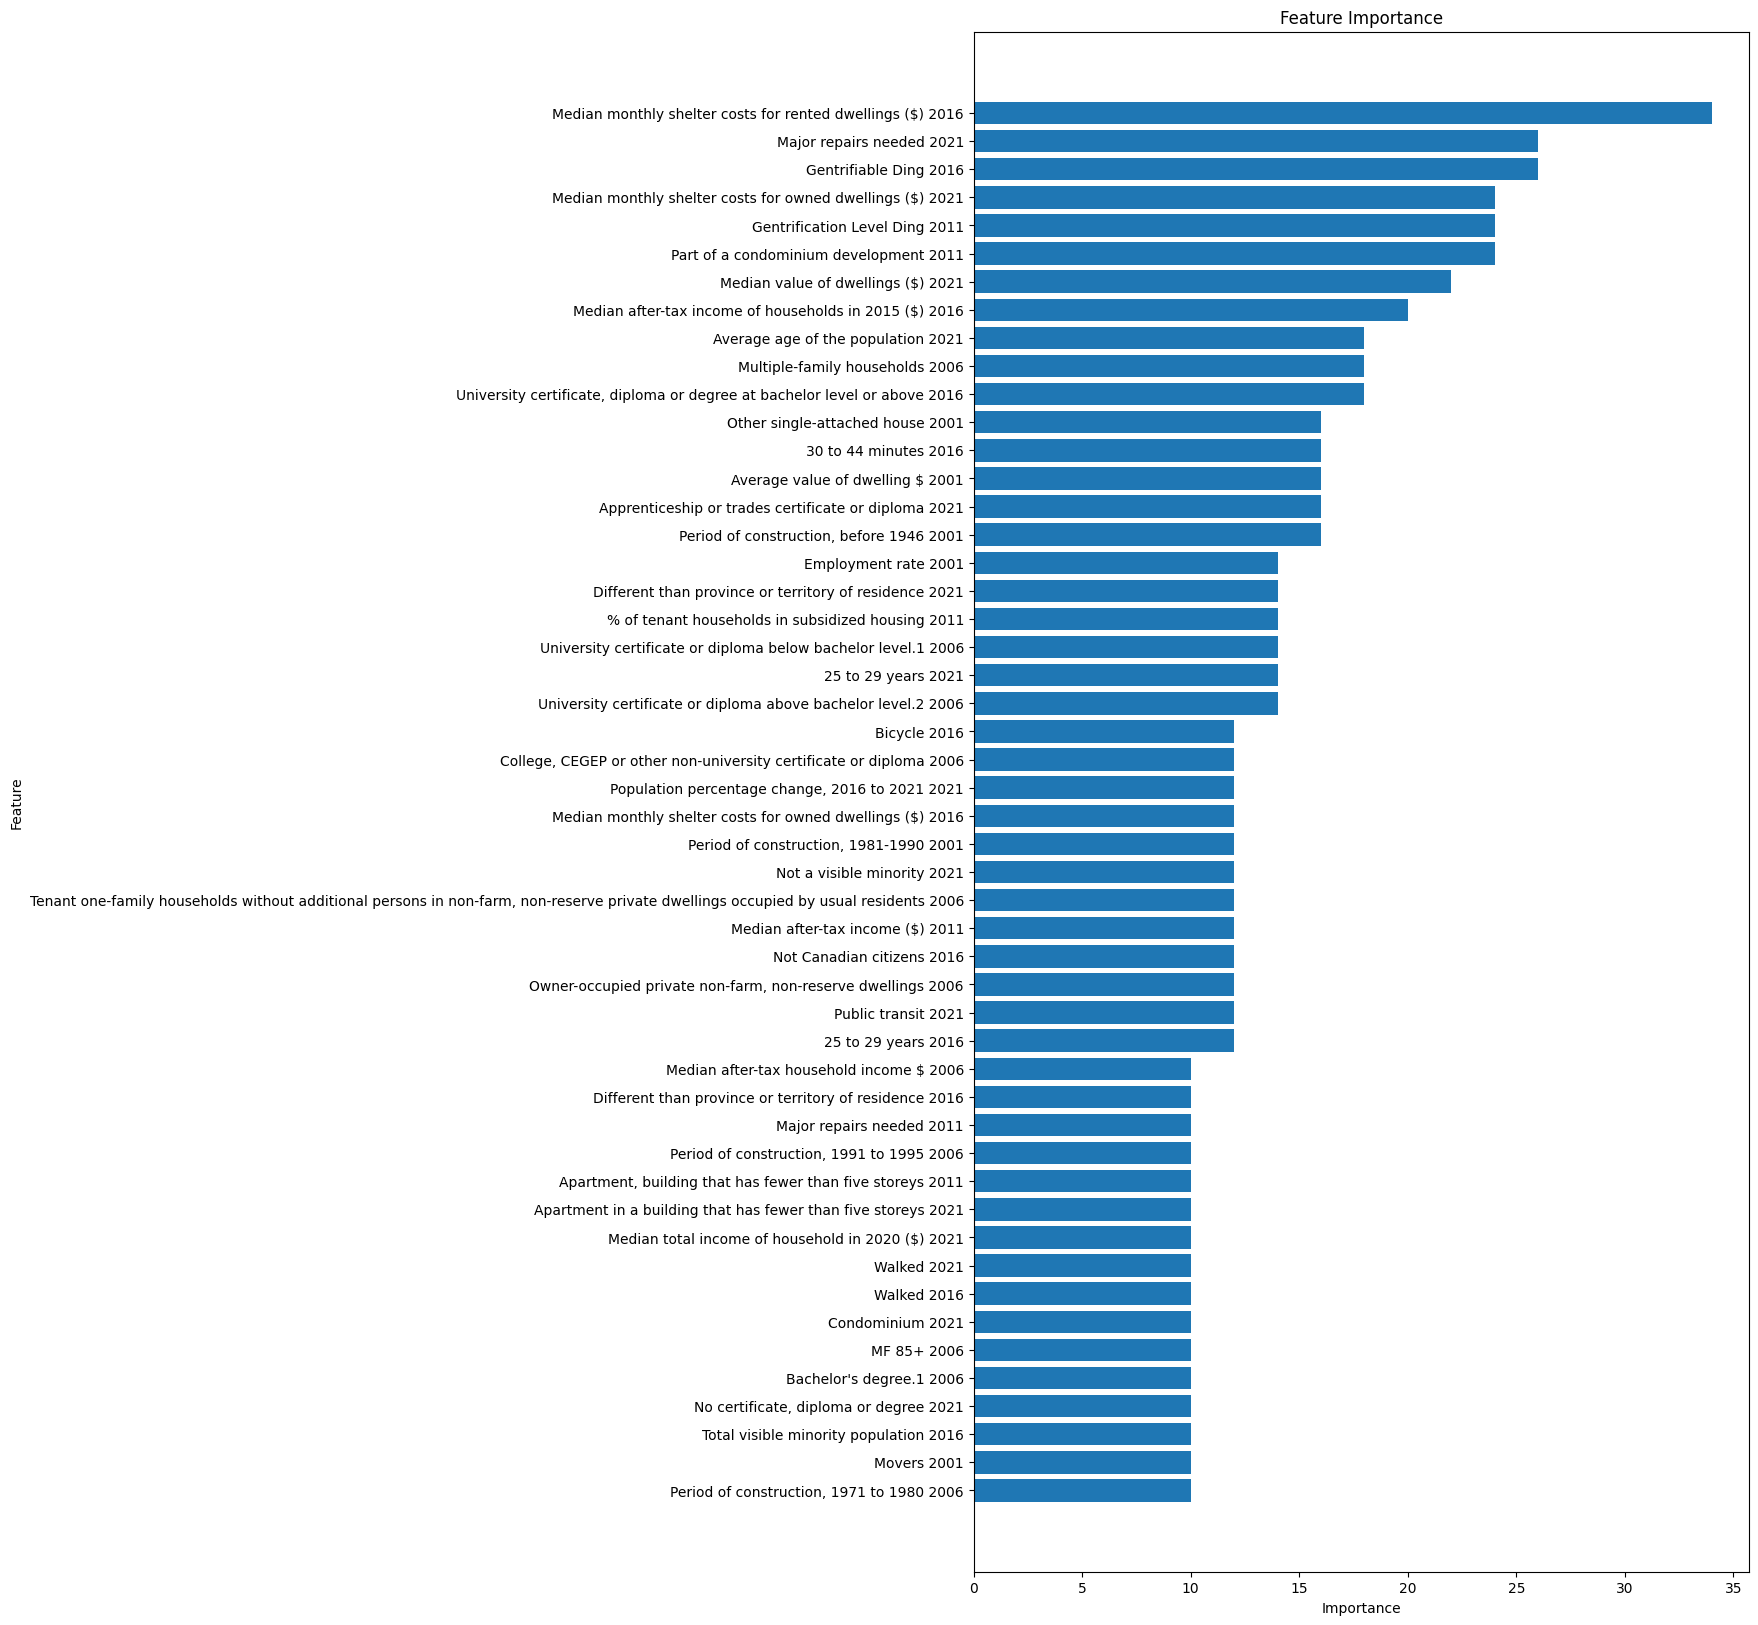

                                               Feature  Importance
207  Median monthly shelter costs for rented dwelli...        34.0
255                          Major repairs needed 2021        26.0
286                             Gentrifiable Ding 2016        26.0
257  Median monthly shelter costs for owned dwellin...        24.0
289                     Gentrification Level Ding 2011        24.0
157             Part of a condominium development 2011        24.0
259                 Median value of dwellings ($) 2021        22.0
189  Median after-tax income of households in 2015 ...        20.0
238                 Average age of the population 2021        18.0
57                     Multiple-family households 2006        18.0
214  University certificate, diploma or degree at b...        18.0
27                    Other single-attached house 2001        16.0
224                              30 to 44 minutes 2016        16.0
9                     Average value of dwelling $ 2001        

In [30]:
# Extract and plot feature importance
importance = bst.get_score(importance_type='weight')
importance_df = pd.DataFrame(importance.items(), columns=['Feature', 'Importance']).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 20))
plt.barh(importance_df['Feature'].iloc[:50], importance_df['Importance'].iloc[:50])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

print(importance_df.head(50))

# 2 Predict Gentrification for 2021

# 3 Predict Gentrification for 2026